# Fono ištrynimas

In [1]:
from datetime import datetime
import math
import os
import random
import numpy as np
from PIL import Image
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

!wget http://klevas.mif.vu.lt/~mif28413/gmm/coco_persons_val.zip
!unzip -q coco_persons_val.zip
!wget http://klevas.mif.vu.lt/~mif28413/gmm/background_model.pth

Device: cuda:0
--2026-04-15 15:07:37--  http://klevas.mif.vu.lt/~mif28413/gmm/coco_persons_val.zip
Resolving klevas.mif.vu.lt (klevas.mif.vu.lt)... 193.219.42.12
Connecting to klevas.mif.vu.lt (klevas.mif.vu.lt)|193.219.42.12|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 52308834 (50M) [application/zip]
Saving to: ‘coco_persons_val.zip’

coco_persons_val.zi 100%[===================>]  49.88M  13.9MB/s    in 3.8s    

2026-04-15 15:07:41 (13.3 MB/s) - ‘coco_persons_val.zip’ saved [52308834/52308834]

--2026-04-15 15:07:42--  http://klevas.mif.vu.lt/~mif28413/gmm/background_model.pth
Resolving klevas.mif.vu.lt (klevas.mif.vu.lt)... 193.219.42.12
Connecting to klevas.mif.vu.lt (klevas.mif.vu.lt)|193.219.42.12|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1785591 (1.7M)
Saving to: ‘background_model.pth’

background_model.pt 100%[===================>]   1.70M  1.60MB/s    in 1.1s    

2026-04-15 15:07:43 (1.60 MB/s) - ‘background_model.p

## Duomenų rinkinys

In [2]:
class BackgroundDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, is_train = False):
        self.is_train = is_train
        self.img_dir = os.path.join(root_dir, 'img')
        self.mask_dir = os.path.join(root_dir, 'mask')

        self.img_list = []
        for fn in os.listdir(self.img_dir):
            _, ext = os.path.splitext(fn)
            if ext == '.jpg':
                self.img_list.append(fn)

    def __len__(self):
        return len(self.img_list)

    def transform(self, img, mask):
        if self.is_train:
            pad_x = math.ceil(max(0, 256 - img.width) / 2)
            pad_y = math.ceil(max(0, 256 - img.height) / 2)
            img = transforms.functional.pad(img, [pad_x, pad_y])
            mask = transforms.functional.pad(mask, [pad_x, pad_y])
            crop_params = transforms.RandomCrop.get_params(img, output_size = (256, 256))
            img = transforms.functional.crop(img, *crop_params)
            mask = transforms.functional.crop(mask, *crop_params)

            if random.random() > 0.5:
                img = transforms.functional.hflip(img)
                mask = transforms.functional.hflip(mask)
        else:
            pad_x = math.ceil(img.width / 8) * 8 - img.width
            pad_y = math.ceil(img.height / 8) * 8 - img.height
            img = transforms.functional.pad(img, [0, 0, pad_x, pad_y])
            mask = transforms.functional.pad(mask, [0, 0, pad_x, pad_y])

        img = transforms.functional.to_tensor(img)
        img = transforms.functional.normalize(img, (0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        mask = transforms.functional.to_tensor(mask)

        return img, mask

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.img_list[idx])
        mask_name = os.path.join(self.mask_dir, self.img_list[idx] + '.png')

        img = Image.open(img_name)
        mask = Image.open(mask_name)

        return self.transform(img.convert('RGB'), mask)

## Mokymo ir testavimo funkcijos

In [3]:
def seconds_to_time(seconds):
    s = int(seconds) % 60
    m = int(seconds) // 60
    if m < 1:
        return f'{s}s'
    h = m // 60
    m = m % 60
    if h < 1:
        return f'{m}m{s}s'
    return f'{h}h{m}m{s}s'

In [4]:
def train_epoch(optimizer, loss_func, model, loader):
  model.train()
  loss_acum = np.array([], dtype = np.float32)

  for data in loader:
    images = data[0].to(device)
    mask = data[1].to(device)

    pred = model(images)
    loss = loss_func(pred, mask)
    loss_acum = np.append(loss_acum, loss.cpu().detach().numpy())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  return np.mean(loss_acum)

In [5]:
def evaluate(model, loader):
  model.eval()

  total_iou = 0.0
  total_predictions = 0

  for data in loader:
    images = data[0].to(device)
    mask = data[1].numpy()

    with torch.no_grad():
      pred = model(images)
    pred = pred.cpu().detach().numpy()

    mask = mask > 0.5
    pred = pred > 0.5

    intersection = np.sum(np.bitwise_and(mask, pred))
    union = np.sum(np.bitwise_or(mask, pred))

    iou = intersection / union

    total_iou += iou
    total_predictions += 1

  mean_iou = total_iou / total_predictions
  return mean_iou

In [6]:
def train_and_eval(model, loader_train, loader_valid, epoch_count = 10, lr = 1e-3):
  loss_func = torch.nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = lr)

  start_time = datetime.now()

  train_iou_acum = []
  valid_iou_acum = []
  for epoch in range(epoch_count):
    loss = train_epoch(optimizer, loss_func, model, loader_train)

    train_iou = evaluate(model, loader_train)
    train_iou_acum.append(train_iou)
    valid_iou = evaluate(model, loader_valid)
    valid_iou_acum.append(valid_iou)

    current_time = datetime.now()
    elapsed = seconds_to_time((current_time - start_time).total_seconds())
    print(f'Epoch: {epoch}, Time: {elapsed}, Training loss: {loss}')
    print(f'  Training IoU: {np.round(train_iou * 100)}, Validation IoU: {np.round(valid_iou * 100)}')

  return train_iou_acum, valid_iou_acum

In [7]:
def plot_iou(train_iou, valid_iou):
  plt.clf()
  plt.plot(train_iou, 'b', label = 'Training IoU')
  plt.plot(valid_iou, 'r', label = 'Validation IoU')
  plt.ylim(0.0, 1.0)
  plt.legend()
  plt.show()

In [17]:
def show_image(img, mask):
  plt.clf()
  fig, axs = plt.subplots(2, 1, figsize = (5, 5*2))

  axs[0].imshow(img.cpu().numpy().transpose((1, 2, 0)) * 0.5 + 0.5)
  axs[1].imshow(mask.cpu().numpy().transpose((1, 2, 0)) > 0.5, vmin = 0, vmax = 1)
  # axs[1].imshow(mask.cpu().numpy().transpose((1, 2, 0)), vmin = 0, vmax = 1)

  plt.show()

## Modelis ir duomenys

In [9]:
class FCNNet(torch.nn.Module):
  def __init__(self, in_channels):
    super().__init__()

    self.conv1_1 = torch.nn.Conv2d(in_channels, 16, (3, 3), padding = 'same')
    self.relu1_1 = torch.nn.ReLU()
    self.conv1_2 = torch.nn.Conv2d(16, 16, (3, 3), padding = 'same')
    self.relu1_2 = torch.nn.ReLU()

    self.pool2 = torch.nn.MaxPool2d((2, 2), (2, 2))
    self.conv2_1 = torch.nn.Conv2d(16, 32, (3, 3), padding = 'same')
    self.relu2_1 = torch.nn.ReLU()
    self.conv2_2 = torch.nn.Conv2d(32, 32, (3, 3), padding = 'same')
    self.relu2_2 = torch.nn.ReLU()

    self.pool3 = torch.nn.MaxPool2d((2, 2), (2, 2))
    self.conv3_1 = torch.nn.Conv2d(32, 64, (3, 3), padding = 'same')
    self.relu3_1 = torch.nn.ReLU()
    self.conv3_2 = torch.nn.Conv2d(64, 64, (3, 3), padding = 'same')
    self.relu3_2 = torch.nn.ReLU()

    self.pool4 = torch.nn.MaxPool2d((2, 2), (2, 2))
    self.conv4_1 = torch.nn.Conv2d(64, 128, (3, 3), padding = 'same')
    self.relu4_1 = torch.nn.ReLU()
    self.conv4_2 = torch.nn.Conv2d(128, 128, (3, 3), padding = 'same')
    self.relu4_2 = torch.nn.ReLU()
    self.conv4_3 = torch.nn.Conv2d(128, 64, (3, 3), padding = 'same')
    self.relu4_3 = torch.nn.ReLU()
    self.upscale4 = torch.nn.Upsample(scale_factor = 2)

    self.conv5_1 = torch.nn.Conv2d(64, 64, (3, 3), padding = 'same')
    self.relu5_1 = torch.nn.ReLU()
    self.conv5_2 = torch.nn.Conv2d(64, 32, (3, 3), padding = 'same')
    self.relu5_2 = torch.nn.ReLU()
    self.upscale5 = torch.nn.Upsample(scale_factor = 2)

    self.conv6_1 = torch.nn.Conv2d(32, 32, (3, 3), padding = 'same')
    self.relu6_1 = torch.nn.ReLU()
    self.conv6_2 = torch.nn.Conv2d(32, 16, (3, 3), padding = 'same')
    self.relu6_2 = torch.nn.ReLU()
    self.upscale6 = torch.nn.Upsample(scale_factor = 2)

    self.conv7_1 = torch.nn.Conv2d(16, 16, (3, 3), padding = 'same')
    self.relu7_1 = torch.nn.ReLU()
    self.conv7_2 = torch.nn.Conv2d(16, 16, (3, 3), padding = 'same')
    self.relu7_2 = torch.nn.ReLU()

    self.conv8 = torch.nn.Conv2d(16, 1, (1, 1))
    self.sigmoid8 = torch.nn.Sigmoid()

  def forward(self, x):
    block1 = torch.nn.Sequential(
        self.conv1_1,
        self.relu1_1,
        self.conv1_2,
        self.relu1_2
    )(x)
    block2 = torch.nn.Sequential(
        self.pool2,
        self.conv2_1,
        self.relu2_1,
        self.conv2_2,
        self.relu2_2,
    )(block1)
    block3 = torch.nn.Sequential(
        self.pool3,
        self.conv3_1,
        self.relu3_1,
        self.conv3_2,
        self.relu3_2,
    )(block2)
    block4 = torch.nn.Sequential(
        self.pool4,
        self.conv4_1,
        self.relu4_1,
        self.conv4_2,
        self.relu4_2,
        self.conv4_3,
        self.relu4_3,
        self.upscale4,
    )(block3) + block3
    block5 = torch.nn.Sequential(
        self.conv5_1,
        self.relu5_1,
        self.conv5_2,
        self.relu5_2,
        self.upscale5,
    )(block4) + block2
    block6 = torch.nn.Sequential(
        self.conv6_1,
        self.relu6_1,
        self.conv6_2,
        self.relu6_2,
        self.upscale6,
    )(block5) + block1
    block7 = torch.nn.Sequential(
        self.conv7_1,
        self.relu7_1,
        self.conv7_2,
        self.relu7_2,
    )(block6)
    block8 = torch.nn.Sequential(
        self.conv8,
        self.sigmoid8
    )(block7)
    return block8

In [10]:
train_dataset = BackgroundDataset('val', is_train = True)
valid_dataset = BackgroundDataset('val', is_train = False)

num_workers = 2
batch_size = 32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size = 1, num_workers = num_workers, shuffle = False)

print(f'Train: {len(train_dataset)}, Test: {len(valid_dataset)}')

Train: 372, Test: 372


## Mokymas ir testavimas

Parameter count: 441,233
Epoch: 0, Time: 11s, Training loss: 0.6938102841377258
  Training IoU: 43.0, Validation IoU: 38.0
Epoch: 1, Time: 21s, Training loss: 0.690507709980011
  Training IoU: 0.0, Validation IoU: 0.0
Epoch: 2, Time: 33s, Training loss: 0.6908798217773438
  Training IoU: 36.0, Validation IoU: 34.0


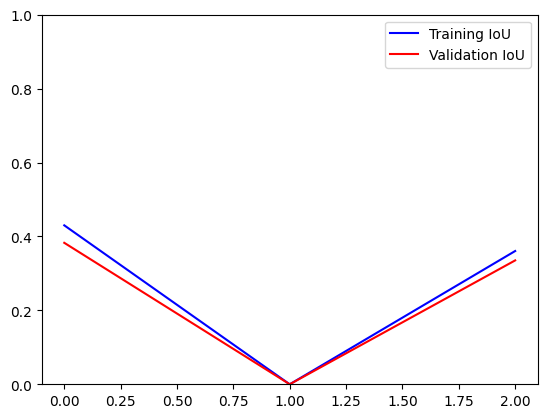

In [12]:
model = FCNNet(train_dataset[0][0].shape[0]).to(device)
print(f'Parameter count: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

train_iou, valid_iou = train_and_eval(model, train_loader, valid_loader, epoch_count = 3, lr = 1e-3)
plot_iou(train_iou, valid_iou)

# torch.save(model, 'background_model.pth')

<Figure size 640x480 with 0 Axes>

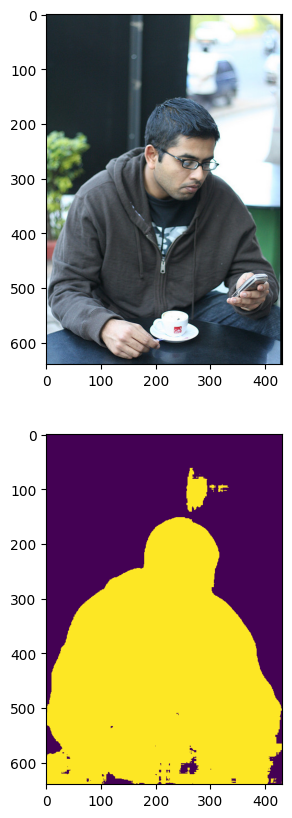

In [19]:
model = torch.load('background_model.pth', weights_only = False).to(device)

img = valid_dataset[15][0]
mask = model(img.unsqueeze(0).to(device)).cpu().detach().squeeze(0)

show_image(img, mask)